# Baseline

**과제**: 자연 풍경 사진을 6개 클래스로 분류한다 —  
`buildings` / `forest` / `glacier` / `mountain` / `sea` / `street` · **지표는 Accuracy**

## 0. 환경 확인

In [1]:
import os, time, math, random, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
from pathlib import Path

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEVICE)
if DEVICE == "cuda":
    print("GPU:", torch.cuda.get_device_name(0),
          f"| {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
else:
    print("⚠️  GPU가 꺼져 있습니다. 런타임 → 런타임 유형 변경 → T4 GPU 로 켜고 다시 실행하세요.")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

torch 2.14.0+cu132 | device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU | 8.5 GB


## 1. 데이터 받기

In [ ]:
# 데이터 다운로드 받아서 zip 파일 압축 해제
!unzip -q -o ./data.zip -d .

DATA = Path("./data")          # train/ test/ train.csv sample_submission.csv 가 있는 폴더
if not DATA.exists():                 # 로컬/다른 환경에서 실행할 때
    DATA = Path("../out")

train_df = pd.read_csv(DATA / "train.csv", dtype={"id": str})
sub      = pd.read_csv(DATA / "sample_submission.csv", dtype={"id": str})
CLASSES  = sorted(train_df["label"].unique())
C2I      = {c: i for i, c in enumerate(CLASSES)}

print("train", train_df.shape, "| test", sub.shape)
print("클래스:", CLASSES)
print(train_df["label"].value_counts().to_string())

train (14034, 2) | test (3000, 2)
클래스: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
label
mountain     2512
glacier      2404
street       2382
sea          2274
forest       2271
buildings    2191


## 2. 이미지를 통째로 RAM에 올린다

In [3]:
from PIL import Image
IMG = 128        # 배포된 이미지 크기

def load_split(folder, ids):
    # uint8 텐서로 한 번에 올려 둔다. JPEG 디코딩을 매 epoch 반복하지 않기 위해서다.
    X = torch.empty(len(ids), 3, IMG, IMG, dtype=torch.uint8)
    for i, fid in enumerate(ids):
        im = Image.open(folder / f"{fid}.jpg").convert("RGB")
        if im.size != (IMG, IMG): im = im.resize((IMG, IMG), Image.BILINEAR)
        X[i] = torch.from_numpy(np.asarray(im)).permute(2, 0, 1)
        if (i+1) % 2000 == 0: print(f"  {i+1}/{len(ids)}", end="\r")
    return X

CACHE = Path("cache.pt")
if CACHE.exists():
    blob = torch.load(CACHE); Xtr_all, Xte = blob["tr"], blob["te"]
    print("캐시에서 로드")
else:
    t0 = time.time()
    Xtr_all = load_split(DATA/"images/train", train_df["id"].tolist())
    Xte     = load_split(DATA/"images/test",  sub["id"].tolist())
    torch.save({"tr": Xtr_all, "te": Xte}, CACHE)
    print(f"이미지 로드 {time.time()-t0:.1f}s")

ytr_all = torch.tensor([C2I[l] for l in train_df["label"]])
print(f"train {tuple(Xtr_all.shape)}  test {tuple(Xte.shape)}  "
      f"메모리 {(Xtr_all.numel()+Xte.numel())/1e6:.0f} MB")

캐시에서 로드
train (14034, 3, 128, 128)  test (3000, 3, 128, 128)  메모리 837 MB


> **왜 이렇게 하는가**: Colab에서 이미지 학습이 느린 가장 흔한 원인은 GPU가 아니라  
> **매 epoch마다 JPEG를 디스크에서 읽고 디코딩하는 것**입니다.  
> 한 번 `uint8` 텐서로 올려 두면 그 비용이 사라지고, 이 데이터는 다 합쳐 몇백 MB라 RAM에 충분히 들어갑니다.  
> `cache.pt`로 저장해 두면 **세션이 끊겨도 다시 읽을 필요가 없습니다.** (Colab에서 중요)

## 3. 데이터 처리
### 3-1. 데이터 분리

In [4]:
from sklearn.model_selection import train_test_split
idx_tr, idx_va = train_test_split(np.arange(len(ytr_all)), test_size=0.15,
                                  stratify=ytr_all.numpy(), random_state=SEED)
print(f"학습 {len(idx_tr):,} / 검증 {len(idx_va):,}")

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1)

def batches(X, y, idx, bs, shuffle):
    order = np.random.permutation(idx) if shuffle else idx
    for i in range(0, len(order), bs):
        sel = order[i:i+bs]
        xb = X[sel].to(DEVICE, non_blocking=True).float().div_(255)
        xb = (xb - MEAN.to(DEVICE)) / STD.to(DEVICE)        # 정규화만. augmentation 없음.
        yield xb, (y[sel].to(DEVICE) if y is not None else None)

학습 11,928 / 검증 2,106


### 3-2. 데이터 증강
현실에 있을 법한 사진을 만들어낸다

#### 사전 EDA

증강은 "아무거나 세게 흔들수록 좋다"가 아닙니다. **데이터가 실제로 어떻게 생겼는지 먼저 보고**
그 분포 안에서 "있을 법한" 변형만 골라야 합니다. 그래서 먼저 확인할 것:

1. **파일 수준** — 해상도 / 컬러모드 / 파일 크기가 균일한가? → 리사이즈·크롭 범위의 근거
2. **색상 대역** — 채널별 최소/최대/평균/표준편차, 픽셀값 히스토그램, 0·255에 몰린(clipping) 비율
   → 밝기·대비를 얼마나 흔들어도 되는지, 정규화 상수를 무엇으로 쓸지의 근거
3. **클래스별 색 분포** — 클래스마다 주요 색이 다른가?
   → **색이 곧 정답 신호라면 색을 심하게 바꾸는 증강은 독**이 됩니다

In [5]:
# ---------- EDA (1) 파일 수준 점검 : ./data 의 실제 이미지 파일을 본다 ----------
from collections import Counter

train_dir, test_dir = DATA/"images/train", DATA/"images/test"
tr_files, te_files  = sorted(train_dir.glob("*.jpg")), sorted(test_dir.glob("*.jpg"))
print(f"파일 수   train {len(tr_files):,}장 / test {len(te_files):,}장   (train.csv {len(train_df):,}행)")

PROBE = 3000                                   # 헤더만 읽어 보는 표본 (전수 검사는 느리다)
sizes, modes, kb = Counter(), Counter(), []
for p in tr_files[:PROBE]:
    with Image.open(p) as im:
        sizes[im.size] += 1
        modes[im.mode] += 1
    kb.append(p.stat().st_size / 1024)

print("해상도    ", sizes.most_common(3))
print("컬러모드  ", modes.most_common(3))
print(f"파일크기   평균 {np.mean(kb):.1f}KB   min {np.min(kb):.1f}  max {np.max(kb):.1f}")
print(f"클래스 균형  최다/최소 = {train_df['label'].value_counts().max()}/"
      f"{train_df['label'].value_counts().min()} "
      f"= {train_df['label'].value_counts().max()/train_df['label'].value_counts().min():.2f}배")

파일 수   train 14,034장 / test 3,000장   (train.csv 14,034행)
해상도     [((128, 128), 3000)]
컬러모드   [('RGB', 3000)]
파일크기   평균 6.8KB   min 2.7  max 11.5
클래스 균형  최다/최소 = 2512/2191 = 1.15배


In [6]:
# ---------- EDA (2) 색상 대역 통계 : 이미 RAM에 올린 uint8 텐서로 계산한다 ----------
# 14,034장 x 3 x 128 x 128 을 float으로 한 번에 펼치면 2.8GB라 청크로 나눠 누적한다.
def channel_stats(X, chunk=1024):
    n, H, W = X.shape[0], X.shape[2], X.shape[3]
    s   = torch.zeros(3, dtype=torch.float64)      # sum
    ss  = torch.zeros(3, dtype=torch.float64)      # sum of squares
    per_img = torch.empty(n, 3)                    # 이미지 1장당 채널 평균
    hist    = torch.zeros(3, 256, dtype=torch.int64)
    for i in range(0, n, chunk):
        c = X[i:i+chunk]
        f = c.float().div(255)
        per_img[i:i+chunk] = f.mean(dim=(2, 3))
        s  += f.sum(dim=(0, 2, 3)).double()
        ss += (f ** 2).sum(dim=(0, 2, 3)).double()
        for ch in range(3):
            hist[ch] += torch.bincount(c[:, ch].reshape(-1).long(), minlength=256)
    npix = n * H * W
    mean = (s / npix).float()
    std  = (ss / npix - (s / npix) ** 2).sqrt().float()
    return mean, std, per_img, hist

t0 = time.time()
DATA_MEAN, DATA_STD, PER_IMG, HIST = channel_stats(Xtr_all)
print(f"통계 계산 {time.time()-t0:.1f}s\n")

for ch, nm in enumerate("RGB"):
    h = HIST[ch].float()
    q = torch.cumsum(h, 0) / h.sum()
    p1, p99 = int((q < 0.01).sum()), int((q < 0.99).sum())
    print(f"{nm}  mean {DATA_MEAN[ch]:.4f}  std {DATA_STD[ch]:.4f}  "
          f"min {int((h>0).nonzero()[0]):3d}  max {int((h>0).nonzero()[-1]):3d}  "
          f"1%~99% 구간 {p1:3d}~{p99:3d}")

tot = HIST.sum().item()
print(f"\n포화 픽셀 비율   0에 붙은 값 {HIST[:,0].sum().item()/tot*100:.2f}%  "
      f"255에 붙은 값 {HIST[:,255].sum().item()/tot*100:.2f}%")
print(f"데이터셋 평균/표준편차  mean={[round(v,4) for v in DATA_MEAN.tolist()]}  "
      f"std={[round(v,4) for v in DATA_STD.tolist()]}")
print(f"ImageNet 상수          mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]")

통계 계산 1.9s

R  mean 0.4302  std 0.2571  min   0  max 255  1%~99% 구간   1~252
G  mean 0.4575  std 0.2561  min   0  max 255  1%~99% 구간   3~252
B  mean 0.4540  std 0.2886  min   0  max 255  1%~99% 구간   0~254

포화 픽셀 비율   0에 붙은 값 0.83%  255에 붙은 값 0.58%
데이터셋 평균/표준편차  mean=[0.4302, 0.4575, 0.454]  std=[0.2571, 0.2561, 0.2886]
ImageNet 상수          mean=[0.485, 0.456, 0.406]  std=[0.229, 0.224, 0.225]


               R      G      B  bright  GB_gap
label                                         
buildings  0.450  0.459  0.464   0.458  -0.005
forest     0.328  0.356  0.243   0.309   0.113
glacier    0.473  0.532  0.582   0.529  -0.051
mountain   0.440  0.483  0.510   0.477  -0.027
sea        0.458  0.495  0.514   0.489  -0.018
street     0.428  0.415  0.401   0.415   0.014


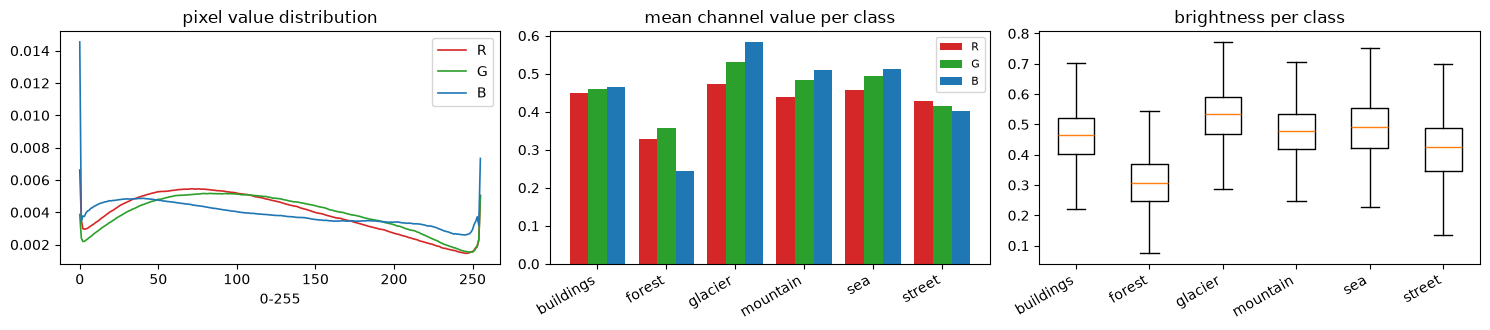

In [7]:
# ---------- EDA (3) 클래스별 색 분포 : 색이 정답 신호인지 확인한다 ----------
import matplotlib.pyplot as plt

eda = pd.DataFrame(PER_IMG.numpy(), columns=["R", "G", "B"])
eda["label"]  = train_df["label"].values
eda["bright"] = eda[["R", "G", "B"]].mean(axis=1)          # 밝기 = 채널 평균
eda["GB_gap"] = eda["G"] - eda["B"]                        # 초록-파랑 차이 (숲 vs 바다/빙하)

by_cls = eda.groupby("label")[["R", "G", "B", "bright", "GB_gap"]].agg(["mean", "std"]).round(3)
print(by_cls.xs("mean", axis=1, level=1).to_string())

fig, ax = plt.subplots(1, 3, figsize=(15, 3.4))

# (a) 채널별 픽셀값 히스토그램
for ch, (nm, col) in enumerate(zip("RGB", ["tab:red", "tab:green", "tab:blue"])):
    ax[0].plot(np.arange(256), HIST[ch].numpy() / HIST[ch].sum().item(), color=col, lw=1.2, label=nm)
ax[0].set_title("pixel value distribution"); ax[0].set_xlabel("0-255"); ax[0].legend()

# (b) 클래스별 평균 RGB
cls_mean = eda.groupby("label")[["R", "G", "B"]].mean().loc[CLASSES]
x = np.arange(len(CLASSES)); w = 0.27
for k, (nm, col) in enumerate(zip("RGB", ["tab:red", "tab:green", "tab:blue"])):
    ax[1].bar(x + (k - 1) * w, cls_mean[nm], w, color=col, label=nm)
ax[1].set_xticks(x); ax[1].set_xticklabels(CLASSES, rotation=30, ha="right")
ax[1].set_title("mean channel value per class"); ax[1].legend(fontsize=8)

# (c) 클래스별 밝기 분포
ax[2].boxplot([eda.loc[eda.label == c, "bright"].values for c in CLASSES], showfliers=False)
ax[2].set_xticks(np.arange(1, len(CLASSES) + 1))
ax[2].set_xticklabels(CLASSES, rotation=30, ha="right")
ax[2].set_title("brightness per class")

plt.tight_layout(); plt.show()

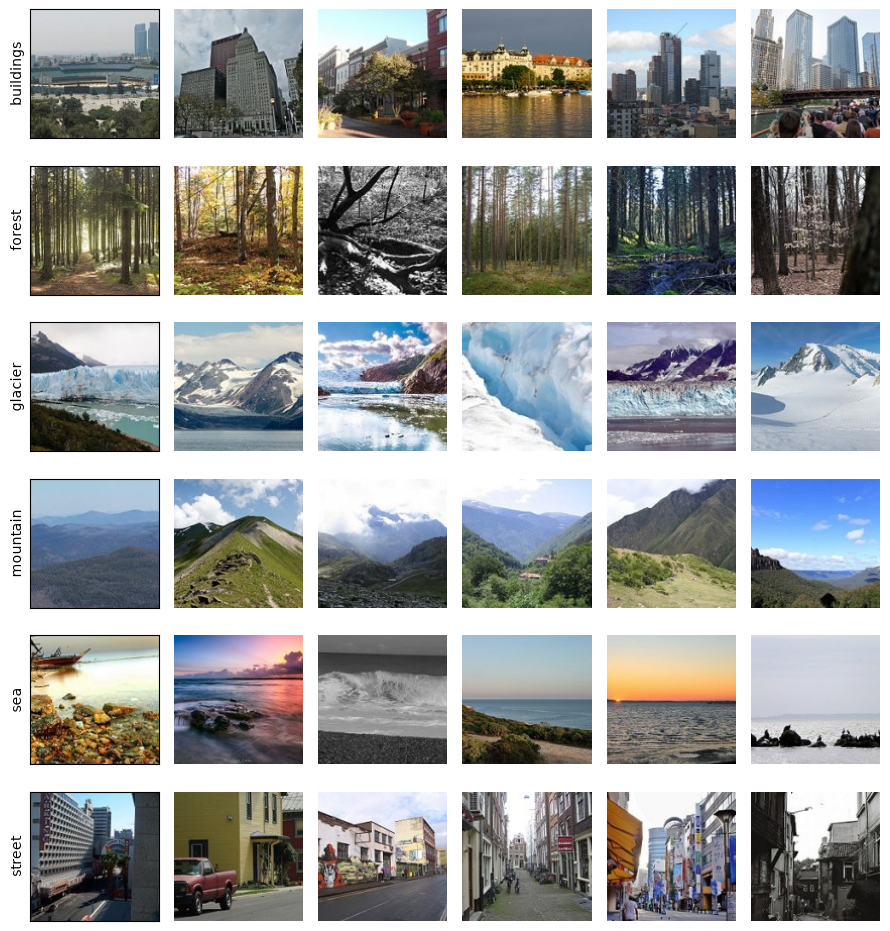

In [8]:
# ---------- EDA (4) 눈으로 보기 : 클래스별 샘플 ----------
rng = np.random.RandomState(SEED)
NS  = 6
fig, ax = plt.subplots(len(CLASSES), NS, figsize=(NS * 1.5, len(CLASSES) * 1.6))
for r, c in enumerate(CLASSES):
    pool = np.where(train_df["label"].values == c)[0]
    for k, j in enumerate(rng.choice(pool, NS, replace=False)):
        ax[r, k].imshow(Xtr_all[j].permute(1, 2, 0).numpy()); ax[r, k].axis("off")
    ax[r, 0].set_ylabel(c)
    ax[r, 0].axis("on"); ax[r, 0].set_xticks([]); ax[r, 0].set_yticks([])
plt.tight_layout(); plt.show()

#### EDA 결론 → 증강 설계

| 관찰 | 증강 설계에 주는 뜻 |
|---|---|
| 전 이미지가 **128×128 RGB**로 이미 균일 | 리사이즈는 불필요. **RandomResizedCrop**으로 "조금 당겨 찍은 사진"만 만든다 |
| 픽셀값이 0~255 **전 대역**에 퍼져 있고, 0/255 포화 픽셀은 1% 미만 | 밝기·대비를 ±20% 정도 흔들어도 정보가 잘려 나가지 않는다 |
| `forest`는 **G 높고 B 매우 낮음**, `glacier`/`sea`는 **B가 가장 높음** | **색조(Hue)가 클래스 신호다** → `ChannelShuffle`·`ToGray`·큰 Hue shift는 **금지**, 색 변형은 약하게만 |
| 클래스별 밝기 차이가 뚜렷 (`forest` 0.31 vs `glacier` 0.53) | 밝기 증강도 과하면 클래스 단서를 지운다 → `brightness_limit`은 0.2 수준 |
| 자연 풍경 = **위/아래가 정해진 장면** (하늘 위, 땅 아래) | `VerticalFlip`·90도 회전은 **금지**, `HorizontalFlip`과 ±12도 회전만 허용 |
| 데이터셋 통계 `mean≈[0.430, 0.457, 0.454]`가 ImageNet과 크게 다르지 않음 | 전이학습 모델의 사전학습 분포를 맞추기 위해 **ImageNet 상수로 정규화** (3-1의 `MEAN`/`STD`와 동일하게 유지) |

즉 **기하 변형은 넉넉하게, 색 변형은 조심스럽게**가 이 데이터의 정답입니다.

In [9]:
# albumentations : 증강 파이프라인
# !pip install -q albumentations          # Colab 등에서 처음 실행할 때만
import albumentations as A, cv2
from albumentations.pytorch import ToTensorV2
print("albumentations", A.__version__)

# 정규화 상수 : 전이학습(ImageNet 사전학습) 기준으로 맞춘다. 3-1의 MEAN/STD와 같은 값 → 6번 제출 코드와 호환.
NORM_MEAN, NORM_STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
# EDA로 구한 데이터셋 자체 통계를 쓰고 싶다면 아래 주석을 풀면 된다 (scratch 학습용).
# NORM_MEAN, NORM_STD = tuple(DATA_MEAN.tolist()), tuple(DATA_STD.tolist())

def build_transforms(strength="medium", size=IMG, mean=NORM_MEAN, std=NORM_STD):
    """EDA 결론(기하는 넉넉히, 색은 조심히)을 강도별로 파라미터화한다."""
    geo_p = {"light": 0.4,  "medium": 0.7,  "heavy": 0.9 }[strength]   # 기하 변형 확률
    col_p = {"light": 0.3,  "medium": 0.6,  "heavy": 0.8 }[strength]   # 색 변형 확률
    bl    = {"light": 0.12, "medium": 0.20, "heavy": 0.30}[strength]   # 밝기/대비 폭
    crop  = {"light": (0.85, 1.0), "medium": (0.70, 1.0), "heavy": (0.55, 1.0)}[strength]

    train_tf = A.Compose([
        # --- 기하 : 같은 장면을 다른 각도/거리에서 찍은 것처럼 ---
        A.HorizontalFlip(p=0.5),                       # 좌우만. 풍경은 위아래가 정해져 있다
        A.RandomResizedCrop(size=(size, size), scale=crop, ratio=(0.85, 1.18), p=geo_p),
        A.Affine(scale=(0.92, 1.08), translate_percent=(-0.05, 0.05), rotate=(-12, 12),
                 border_mode=cv2.BORDER_REFLECT_101, p=geo_p * 0.6),
        # --- 색 : 촬영 시간/날씨가 조금 다른 정도까지만 ---
        A.RandomBrightnessContrast(brightness_limit=bl, contrast_limit=bl, p=col_p),
        A.HueSaturationValue(hue_shift_limit=6,        # 색조는 클래스 신호 → 아주 약하게
                             sat_shift_limit=18, val_shift_limit=10, p=col_p * 0.5),
        # --- 화질 : 흔들림/노이즈가 있는 사진도 맞히게 ---
        A.OneOf([A.GaussNoise(std_range=(0.02, 0.08)),
                 A.MotionBlur(blur_limit=3),
                 A.GaussianBlur(blur_limit=3)], p=0.2),
        # --- 가림 : 일부가 가려져도 나머지 단서로 맞히게 (Cutout) ---
        A.CoarseDropout(num_holes_range=(1, 2), hole_height_range=(0.08, 0.20),
                        hole_width_range=(0.08, 0.20), fill=0,
                        p=0.0 if strength == "light" else 0.25),
        A.Normalize(mean=mean, std=std), ToTensorV2(),
    ])
    # 검증/테스트는 절대 증강하지 않는다. 정규화만.
    eval_tf = A.Compose([A.Resize(size, size), A.Normalize(mean=mean, std=std), ToTensorV2()])
    return train_tf, eval_tf

_t, _e = build_transforms("medium")
print(f"train 변환 {len(_t.transforms)}단계 / eval 변환 {len(_e.transforms)}단계")

albumentations 2.0.8
train 변환 9단계 / eval 변환 3단계


In [10]:
# CustomDataset : 이미 RAM에 올려 둔 uint8 텐서에 곧바로 증강을 적용한다 (디스크 재접근 없음)
from torch.utils.data import Dataset, DataLoader

class SceneDataset(Dataset):
    """X: (N,3,H,W) uint8 텐서 / idx: 이 Dataset이 담당할 인덱스 / tf: albumentations Compose"""
    def __init__(self, X, y, idx, tf):
        self.X, self.y, self.tf = X, y, tf
        self.idx = np.asarray(idx)

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j   = int(self.idx[i])
        img = np.ascontiguousarray(self.X[j].permute(1, 2, 0).numpy())   # CHW uint8 -> HWC (albumentations 규약)
        img = self.tf(image=img)["image"]                                # -> 정규화된 float CHW 텐서
        return img, (-1 if self.y is None else int(self.y[j]))

# Windows + 주피터에서는 worker 프로세스가 노트북 전역을 pickle 하지 못해 num_workers=0 이 안전하다.
NUM_WORKERS = 0 if os.name == "nt" else 2

def make_loaders(bs=128, strength="medium", size=IMG):
    train_tf, eval_tf = build_transforms(strength, size)
    tr = DataLoader(SceneDataset(Xtr_all, ytr_all, idx_tr, train_tf), batch_size=bs, shuffle=True,
                    num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"), drop_last=True)
    va = DataLoader(SceneDataset(Xtr_all, ytr_all, idx_va, eval_tf), batch_size=256, shuffle=False,
                    num_workers=NUM_WORKERS, pin_memory=(DEVICE == "cuda"))
    return tr, va

train_loader, val_loader = make_loaders(bs=128, strength="medium")
xb, yb = next(iter(train_loader))
print(f"배치 {tuple(xb.shape)} {xb.dtype}  mean={xb.mean():+.3f} std={xb.std():.3f}  "
      f"(정규화 뒤라 0 근처가 정상)  라벨 예시 {yb[:8].tolist()}")
print(f"스텝 수  train {len(train_loader)} / val {len(val_loader)}")

배치 (128, 3, 128, 128) torch.float32  mean=-0.006 std=1.272  (정규화 뒤라 0 근처가 정상)  라벨 예시 [0, 0, 0, 1, 5, 5, 2, 5]
스텝 수  train 93 / val 9


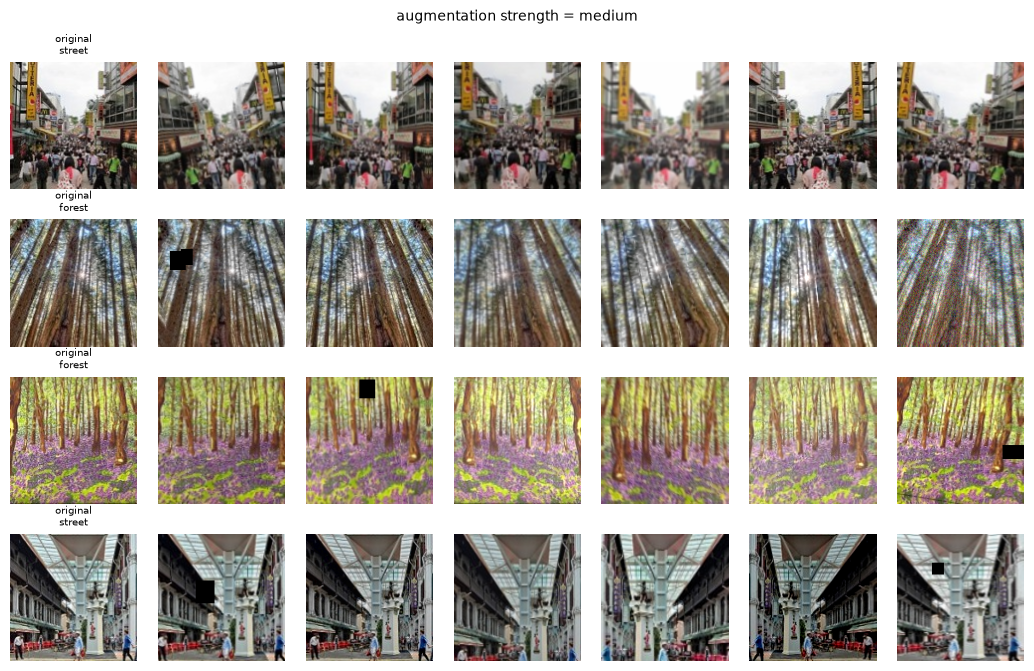

증강 0.36 ms/장  →  1 epoch(11,928장) 당 약 4.3초 추가


In [11]:
# 증강 결과 확인 : "사람이 봐도 같은 클래스인가?"를 반드시 눈으로 검수한다
def denorm(t, mean=NORM_MEAN, std=NORM_STD):
    x = t.permute(1, 2, 0).numpy() * np.array(std) + np.array(mean)
    return np.clip(x, 0, 1)

def show_aug(strength="medium", n_img=4, n_aug=6, seed=SEED):
    tf, _ = build_transforms(strength)
    r = np.random.RandomState(seed)
    picks = r.choice(idx_tr, n_img, replace=False)
    fig, ax = plt.subplots(n_img, n_aug + 1, figsize=(1.5 * (n_aug + 1), 1.7 * n_img))
    for row, j in enumerate(picks):
        org = np.ascontiguousarray(Xtr_all[j].permute(1, 2, 0).numpy())
        ax[row, 0].imshow(org); ax[row, 0].axis("off")
        ax[row, 0].set_title(f"original\n{train_df['label'].iloc[j]}", fontsize=7)
        for col in range(1, n_aug + 1):
            ax[row, col].imshow(denorm(tf(image=org)["image"])); ax[row, col].axis("off")
    fig.suptitle(f"augmentation strength = {strength}", fontsize=10)
    plt.tight_layout(); plt.show()

show_aug("medium")

# 증강 1장당 비용 측정 : 학습 속도에 얼마나 영향을 주는지 확인
tf, _ = build_transforms("medium")
probe = np.ascontiguousarray(Xtr_all[int(idx_tr[0])].permute(1, 2, 0).numpy())
t0 = time.time()
for _ in range(1000): tf(image=probe)
dt = (time.time() - t0) / 1000
print(f"증강 {dt*1000:.2f} ms/장  →  1 epoch({len(idx_tr):,}장) 당 약 {dt*len(idx_tr):.1f}초 추가")

## 4. 모델 구축

**목표**: 사용자가 고른 모델을 SimpleCNN 기준선(증강 없이 15 epoch, **val 0.8993**) 위로 끌어올린다.

이 노트북은 **여러 후보를 비교해 이긴 모델 하나를 자동으로 고르지 않습니다.** 4-4에서 직접 적은 모델만 사용합니다.

진행 방식 —
| 단계 | 내용 |
|---|---|
| 4-1 | `SimpleCNN` — baseline |
| 4-2 | 전이학습 모델 팩토리 (`build_model`) — ResNet / MobileNetV3 / EfficientNet / VGG |
| 4-3 | 공통 학습 루틴 (`train_model`) — 실험끼리 비교가 성립하려면 모델 말고는 전부 같아야 한다 |
| 4-4 | **사용할 모델 선택** — `MODELS`에 직접 적는다 |
| 4-5 | **튜닝** — 모델마다 lr / 증강 강도 / mixup / freeze / batch를 하나씩 바꿔 최적 조합을 찾는다 |
| 4-6 | 모델별 최적 설정 확정 → 5번 본 학습, 6번 제출 파일로 이어진다 |

### 4-1. SimpleCNN (baseline 모델)

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self, n_classes, width=32):
        super().__init__()
        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, 3, padding=1, bias=False), nn.BatchNorm2d(cout), nn.ReLU(inplace=True),
                nn.MaxPool2d(2))
        self.features = nn.Sequential(
            block(3, width),            # 128 -> 64
            block(width, width*2),      #  64 -> 32
            block(width*2, width*4),    #  32 -> 16
            block(width*4, width*8),    #  16 ->  8
        )
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(),
                                  nn.Dropout(0.2), nn.Linear(width*8, n_classes))
    def forward(self, x): return self.head(self.features(x))

BASELINE_ACC = 0.8993        # 증강 없이 15 epoch 학습한 SimpleCNN의 val accuracy = 우리가 넘어야 할 벽

_m = SimpleCNN(len(CLASSES)).to(DEVICE)
print(f"파라미터 수: {sum(p.numel() for p in _m.parameters())/1e6:.2f}M   |   기준선 val acc = {BASELINE_ACC:.4f}")
del _m

파라미터 수: 1.17M   |   기준선 val acc = 0.8993


### 4-2. 전이학습 모델 (torchvision pretrained)

ImageNet 120만 장으로 배운 "가장자리 → 질감 → 물체" 필터를 **그대로 가져와서** 마지막 분류층만 6클래스로 갈아 끼웁니다.
1.4만 장짜리 데이터에서는 바닥부터 배우는 것보다 거의 항상 강합니다.

핵심 두 가지 —
- **분류 헤드 교체**: `resnet*`은 `.fc`, `mobilenet/efficientnet/vgg`는 `.classifier`의 마지막 `Linear`를 바꾼다
- **학습률**: 사전학습 가중치는 이미 좋은 위치에 있으므로 SimpleCNN(3e-3)보다 **한 자릿수 낮은 lr**(2e-4 ~ 6e-4)을 써야 한다.
  높은 lr은 애써 배운 특징을 망가뜨린다(catastrophic forgetting).

입력이 128×128이라 224 기준으로 학습된 모델엔 다소 작지만, 모두 `AdaptiveAvgPool`로 끝나므로 그대로 동작합니다.

In [14]:
# 사용할 pretrained model과 weights를 불러온다
# torchvision 0.13+ 에서는 pretrained=True 가 아니라 weights=... 를 쓴다
from torchvision.models import vgg16, vgg19
from torchvision.models import resnet18, resnet50, resnet101, resnet152
from torchvision.models import mobilenet_v3_small, mobilenet_v3_large
from torchvision.models import efficientnet_b0, efficientnet_b2, efficientnet_b3

from torchvision.models import VGG16_Weights, VGG19_Weights
from torchvision.models import ResNet18_Weights, ResNet50_Weights, ResNet101_Weights, ResNet152_Weights
from torchvision.models import MobileNet_V3_Small_Weights, MobileNet_V3_Large_Weights
from torchvision.models import EfficientNet_B0_Weights, EfficientNet_B2_Weights, EfficientNet_B3_Weights

import torchvision
print("torchvision", torchvision.__version__)

torchvision 0.29.0+cu132


In [15]:
# 후보 모델 목록 : 모델 함수 + 사전학습 weights + 그 모델에 맞는 기본 lr/weight decay
networks = {
    "SimpleCNN":      dict(fn=None,                w=None,                                    lr=3e-3, wd=1e-4),
    "ResNet18":       dict(fn=resnet18,            w=ResNet18_Weights.IMAGENET1K_V1,          lr=5e-4, wd=1e-4),
    "ResNet50":       dict(fn=resnet50,            w=ResNet50_Weights.IMAGENET1K_V2,          lr=3e-4, wd=1e-4),
    "ResNet101":      dict(fn=resnet101,           w=ResNet101_Weights.IMAGENET1K_V2,         lr=2e-4, wd=1e-4),
    "ResNet152":      dict(fn=resnet152,           w=ResNet152_Weights.IMAGENET1K_V2,         lr=2e-4, wd=1e-4),
    "MobileNetV3S":   dict(fn=mobilenet_v3_small,  w=MobileNet_V3_Small_Weights.DEFAULT,      lr=8e-4, wd=1e-5),
    "MobileNetV3L":   dict(fn=mobilenet_v3_large,  w=MobileNet_V3_Large_Weights.DEFAULT,      lr=6e-4, wd=1e-5),
    "EfficientNetB0": dict(fn=efficientnet_b0,     w=EfficientNet_B0_Weights.DEFAULT,         lr=5e-4, wd=1e-5),
    "EfficientNetB2": dict(fn=efficientnet_b2,     w=EfficientNet_B2_Weights.DEFAULT,         lr=4e-4, wd=1e-5),
    "EfficientNetB3": dict(fn=efficientnet_b3,     w=EfficientNet_B3_Weights.DEFAULT,         lr=4e-4, wd=1e-5),
    "VGG19":          dict(fn=vgg19,               w=VGG19_Weights.DEFAULT,                   lr=1e-4, wd=5e-4),
}
print(f"후보 {len(networks)}종 :", ", ".join(networks))

후보 11종 : SimpleCNN, ResNet18, ResNet50, ResNet101, ResNet152, MobileNetV3S, MobileNetV3L, EfficientNetB0, EfficientNetB2, EfficientNetB3, VGG19


In [16]:
def build_model(name, n_classes=len(CLASSES), pretrained=True, dropout=None):
    """이름 하나로 6클래스 분류기를 만들어 준다. 마지막 Linear만 갈아 끼우는 게 전부다."""
    cfg = networks[name]
    if name == "SimpleCNN":
        return SimpleCNN(n_classes).to(DEVICE)

    m = cfg["fn"](weights=cfg["w"] if pretrained else None)

    if hasattr(m, "fc"):                                   # ResNet 계열
        m.fc = nn.Linear(m.fc.in_features, n_classes)
    elif isinstance(getattr(m, "classifier", None), nn.Sequential):   # MobileNet / EfficientNet / VGG
        last = [i for i, l in enumerate(m.classifier) if isinstance(l, nn.Linear)][-1]
        m.classifier[last] = nn.Linear(m.classifier[last].in_features, n_classes)
        if dropout is not None:                            # 과적합 조절용 knob
            for l in m.classifier:
                if isinstance(l, nn.Dropout): l.p = dropout
    else:
        raise ValueError(f"분류 헤드를 못 찾음: {name}")
    return m.to(DEVICE)


def head_params(model):
    """새로 만든 분류 헤드의 파라미터 (사전학습이 안 된 유일한 부분)"""
    if hasattr(model, "fc"):         return list(model.fc.parameters())
    if hasattr(model, "classifier"): return list(model.classifier.parameters())
    return list(model.head.parameters())

def set_backbone_grad(model, flag):
    """freeze/unfreeze : 헤드를 뺀 나머지(백본)의 학습 여부를 켜고 끈다"""
    keep = {id(p) for p in head_params(model)}
    for p in model.parameters():
        if id(p) not in keep: p.requires_grad_(flag)


# 동작 확인 : 각 모델이 (B,6) 로짓을 내는지, 파라미터가 몇 개인지
dummy = torch.zeros(2, 3, IMG, IMG, device=DEVICE)
for nm in ["SimpleCNN", "ResNet50", "MobileNetV3L", "EfficientNetB0"]:
    m = build_model(nm); m.eval()
    with torch.no_grad(): out = m(dummy)
    print(f"{nm:16s} out {tuple(out.shape)}  params {sum(p.numel() for p in m.parameters())/1e6:6.2f}M")
    del m
del dummy; torch.cuda.empty_cache()

SimpleCNN        out (2, 6)  params   1.17M
ResNet50         out (2, 6)  params  23.52M
MobileNetV3L     out (2, 6)  params   4.21M
EfficientNetB0   out (2, 6)  params   4.02M


### 4-3. 공통 학습 루틴

후보를 비교하려면 **모델만 빼고 전부 같아야** 합니다. 그래서 학습 코드를 함수 하나(`train_model`)로 묶습니다.
5번 본 학습도 이 함수를 그대로 씁니다.

기준선 대비 추가된 장치 —
| 장치 | 이유 |
|---|---|
| **OneCycleLR** (warmup + cosine) | 초반에 lr을 천천히 올려 사전학습 가중치가 깨지는 것을 막는다 |
| **Label smoothing 0.05** | 정답에 100% 확신하지 않게 해 과신·과적합을 줄인다 |
| **Gradient clipping** | AMP + 높은 lr 조합에서 가끔 터지는 발산을 막는다 |
| **mixup** (선택) | 두 이미지를 섞어 학습 → 강력한 정규화. 4-5에서 켜고 끄며 비교한다 |
| **freeze warmup** (선택) | 처음 몇 epoch은 헤드만 학습 → 무작위 헤드의 큰 gradient가 백본을 망치는 것을 막는다 |

In [18]:
USE_AMP = (DEVICE == "cuda")

@torch.no_grad()
def evaluate_loader(model, loader):
    model.eval(); correct = n = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
        with torch.amp.autocast(DEVICE, enabled=USE_AMP):
            correct += (model(xb).argmax(1) == yb).sum().item()
        n += len(yb)
    return correct / n

def mixup_batch(x, y, alpha):
    """두 장을 lam:1-lam 비율로 섞는다. 라벨도 같은 비율로 섞어 loss를 계산한다."""
    lam  = float(np.random.beta(alpha, alpha))
    perm = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1 - lam) * x[perm], y, y[perm], lam


def train_model(name_or_model, train_loader, val_loader, epochs=6,
                lr=None, wd=None, label_smoothing=0.05, mixup_alpha=0.0,
                freeze_epochs=0, tag=None, ckpt=None, verbose=True, **build_kw):
    """모델(이름 또는 인스턴스)을 받아 학습하고 {best_acc, history, ...}를 돌려준다."""
    if isinstance(name_or_model, str):
        tag   = tag or name_or_model
        lr    = networks[name_or_model]["lr"] if lr is None else lr
        wd    = networks[name_or_model]["wd"] if wd is None else wd
        model = build_model(name_or_model, **build_kw)
    else:
        model, tag = name_or_model, (tag or "model")
        lr, wd = (lr or 3e-4), (1e-4 if wd is None else wd)

    ckpt   = ckpt or f"ckpt_{tag}.pt"
    opt    = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    steps  = max(1, len(train_loader))
    sched  = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=lr, total_steps=epochs * steps,
                                                 pct_start=0.15, div_factor=10, final_div_factor=100)
    crit   = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
    scaler = torch.amp.GradScaler(DEVICE, enabled=USE_AMP)
    if freeze_epochs > 0: set_backbone_grad(model, False)

    hist, best, t0 = [], 0.0, time.time()
    for ep in range(1, epochs + 1):
        if freeze_epochs and ep == freeze_epochs + 1:       # 헤드가 자리를 잡으면 백본을 푼다
            set_backbone_grad(model, True)
        model.train(); tot = n = correct = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast(DEVICE, enabled=USE_AMP):
                if mixup_alpha > 0:
                    xm, ya, yb2, lam = mixup_batch(xb, yb, mixup_alpha)
                    out  = model(xm)
                    loss = lam * crit(out, ya) + (1 - lam) * crit(out, yb2)
                    ref  = ya                                # 섞인 라벨 중 주된 쪽 기준(근사)
                else:
                    out  = model(xb); loss = crit(out, yb); ref = yb
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            scaler.step(opt); scaler.update(); sched.step()
            tot += loss.item() * len(yb); n += len(yb)
            correct += (out.argmax(1) == ref).sum().item()

        tr_acc = correct / n                                 # 증강된 이미지 기준 학습 정확도
        va_acc = evaluate_loader(model, val_loader)
        hist.append({"epoch": ep, "loss": tot / n, "train_acc": tr_acc, "val_acc": va_acc,
                     "lr": sched.get_last_lr()[0]})
        if va_acc > best:
            best = va_acc; torch.save(model.state_dict(), ckpt)
        if verbose:
            print(f"  [{tag}] ep{ep:2d}  loss={tot/n:.4f}  train={tr_acc:.4f}  val={va_acc:.4f}"
                  f"{'  <- best' if va_acc == best else ''}")

    sec = time.time() - t0
    if verbose:
        print(f"  [{tag}] best val = {best:.4f}   ({sec:.0f}s, {sec/epochs:.1f}s/epoch)\n")
    return {"tag": tag, "best_acc": best, "history": hist, "sec": sec, "ckpt": ckpt,
            "params_M": sum(p.numel() for p in model.parameters()) / 1e6, "model": model}

print("train_model 준비 완료")

train_model 준비 완료


### 4-4. 사용할 모델 선택

이 노트북은 **가장 정확한 모델을 자동으로 고르지 않습니다.**
아래 `MODELS`에 적은 모델만 사용하고, 적은 모델 **각각에 대해** 4-5 튜닝 → 5 학습 → 6 제출 파일 생성이 독립적으로 수행됩니다.

고를 때 참고할 **1 epoch 실측** 비용 (RTX 5060 Laptop 8.5GB, bs=128, 128×128, AMP):

| 모델 | params | s/epoch | VRAM | 1ep val |
|---|---:|---:|---:|---:|
| ResNet18 | 11.2M | 15.2 | 1.2GB | 0.927 |
| ResNet50 | 23.5M | 22.2 | 2.3GB | 0.925 |
| SimpleCNN | 1.2M | 22.4 | 1.9GB | 0.767 |
| MobileNetV3S | 1.5M | 24.3 | 0.5GB | 0.905 |
| ResNet101 | 42.5M | 25.5 | 3.4GB | 0.925 |
| MobileNetV3L | 4.2M | 30.5 | 1.1GB | 0.913 |
| EfficientNetB0 | 4.0M | 31.1 | 2.1GB | 0.926 |
| ResNet152 | 58.2M | 33.6 | 4.7GB | 0.934 |
| EfficientNetB2 | 7.7M | 33.7 | 2.9GB | 0.923 |
| EfficientNetB3 | 10.7M | 42.4 | 3.8GB | 0.921 |
| VGG19 | 139.6M | 48.0 | 4.5GB | 0.933 |

> 1 epoch 성적은 참고용입니다. 사전학습 특징이 바로 먹히는 모델이 초반에 유리하므로 epoch을 늘리면 순위가 바뀝니다.

In [29]:
# 사용할 모델을 직접 적는다. 여러 개 적으면 모델마다 따로 튜닝 -> 학습 -> 제출 파일이 만들어진다.
#   예)  MODELS = ["ResNet50"]
#        MODELS = ["ResNet18", "ResNet152", "EfficientNetB0"]
MODELS = ['VGG19']

print("선택 가능:", ", ".join(networks))
assert MODELS, "MODELS 가 비어 있습니다. 위 목록에서 사용할 모델 이름을 적으세요."
unknown = [m for m in MODELS if m not in networks]
assert not unknown, f"networks 에 없는 이름: {unknown}"
print("선택:", MODELS)

선택 가능: SimpleCNN, ResNet18, ResNet50, ResNet101, ResNet152, MobileNetV3S, MobileNetV3L, EfficientNetB0, EfficientNetB2, EfficientNetB3, VGG19
선택: ['VGG19']


### 4-5. 튜닝

`MODELS`에 적은 **모델마다** 따로, **한 번에 하나씩만** 바꿔 가며 효과를 측정합니다(ablation).
여러 개를 동시에 바꾸면 무엇이 효과를 냈는지 알 수 없습니다.

| 실험 | 바꾸는 것 | 기대 |
|---|---|---|
| `base` | — | 기준 |
| `lr-up` / `lr-down` | 학습률 ×2 / ÷2 | lr은 전이학습에서 가장 영향이 큰 하이퍼파라미터 |
| `aug-light` / `aug-heavy` | 증강 강도 | 증강이 부족하면 과적합, 과하면 학습 자체가 안 된다 |
| `mixup` | mixup α=0.2 | 강한 정규화. 짧은 학습에선 오히려 손해일 수 있다 |
| `freeze1` | 1 epoch 동안 백본 동결 | 초기 헤드의 큰 gradient로부터 사전학습 특징을 보호 |
| `bs64` | 배치 64 | 작은 배치 = 업데이트 횟수 증가 + gradient 노이즈(정규화 효과) |

학습률은 모델마다 적정값이 다르므로 **절대값이 아니라 모델 기본 lr(`networks[...]["lr"]`)의 배수**로 지정합니다.

> 비용: 모델 1종당 `8개 실험 × TUNE_EPOCHS`. ResNet50(20s/epoch) 기준 8×8×20s ≈ **21분/모델**.

In [30]:
TUNE_EPOCHS = 8

TUNE = [
    dict(tag="base"),
    dict(tag="lr-up",     lr_mult=2.0),
    dict(tag="lr-down",   lr_mult=0.5),
    dict(tag="aug-light", strength="light"),
    dict(tag="aug-heavy", strength="heavy"),
    dict(tag="mixup",     mixup_alpha=0.2),
    dict(tag="freeze1",   freeze_epochs=1),
    dict(tag="bs64",      bs=64),
]

loader_cache = {}
def cached_loaders(bs, strength):
    key = (bs, strength)
    if key not in loader_cache: loader_cache[key] = make_loaders(bs=bs, strength=strength)
    return loader_cache[key]

tuned = {}                                   # {모델: {실험: 결과}}
for mdl in MODELS:
    base_lr = networks[mdl]["lr"]
    print(f"{'='*70}\n{mdl} 튜닝  (기본 lr={base_lr:g}, 실험 {len(TUNE)}종 x {TUNE_EPOCHS} epoch)\n{'='*70}")
    tuned[mdl] = {}
    for spec in TUNE:
        spec     = dict(spec)
        tag      = spec.pop("tag")
        bs       = spec.pop("bs", 128)
        strength = spec.pop("strength", "medium")
        mult     = spec.pop("lr_mult", None)
        if mult is not None: spec["lr"] = base_lr * mult
        tl, vl = cached_loaders(bs, strength)
        torch.manual_seed(SEED); np.random.seed(SEED)
        r = train_model(mdl, tl, vl, epochs=TUNE_EPOCHS,
                        tag=f"{mdl}-{tag}", ckpt=f"ckpt_tune_{mdl}_{tag}.pt", **spec)
        r.pop("model")
        r["cfg"] = dict(bs=bs, strength=strength, **spec)
        tuned[mdl][tag] = r
        torch.cuda.empty_cache()

tune_board = pd.DataFrame([
    {"model": mdl, "exp": tag, "best_acc": r["best_acc"], "sec": r["sec"], **r["cfg"],
     "vs_base": r["best_acc"] - tuned[mdl]["base"]["best_acc"]}
    for mdl, exps in tuned.items() for tag, r in exps.items()
]).sort_values(["model", "best_acc"], ascending=[True, False]).reset_index(drop=True)

for mdl in MODELS:
    print(f"\n{'='*70}\n{mdl} 튜닝 결과 (base 대비)\n{'='*70}")
    print(tune_board[tune_board.model == mdl].drop(columns="model").round(4).to_string(index=False))

VGG19 튜닝  (기본 lr=0.0001, 실험 8종 x 8 epoch)


KeyboardInterrupt: 

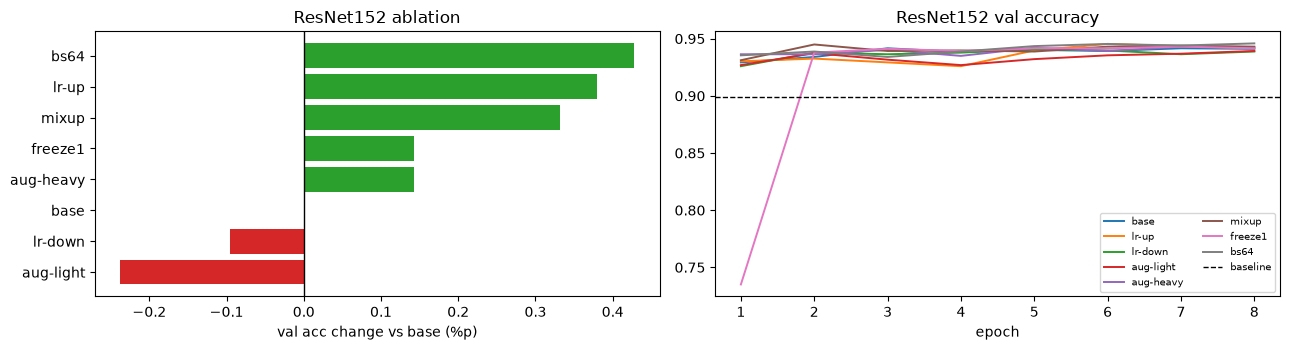

    model       exp  train    val     gap
ResNet152     mixup 0.5670 0.9430 -0.3760
ResNet152 aug-heavy 0.9893 0.9425  0.0468
ResNet152      bs64 0.9937 0.9459  0.0478
ResNet152   lr-down 0.9886 0.9387  0.0498
ResNet152     lr-up 0.9938 0.9416  0.0522
ResNet152   freeze1 0.9939 0.9416  0.0523
ResNet152      base 0.9941 0.9411  0.0530
ResNet152 aug-light 0.9961 0.9392  0.0568


In [21]:
# 모델마다 어떤 변경이 실제로 도움이 됐는지
fig, ax = plt.subplots(len(MODELS), 2, figsize=(13, 3.6 * len(MODELS)), squeeze=False)

for row, mdl in enumerate(MODELS):
    sub_b = tune_board[tune_board.model == mdl].sort_values("vs_base")
    cols  = ["tab:red" if v < 0 else "tab:green" for v in sub_b.vs_base]
    ax[row, 0].barh(sub_b.exp, sub_b.vs_base * 100, color=cols)
    ax[row, 0].axvline(0, c="k", lw=1)
    ax[row, 0].set_xlabel("val acc change vs base (%p)")
    ax[row, 0].set_title(f"{mdl} ablation")

    for tag, r in tuned[mdl].items():
        h = pd.DataFrame(r["history"])
        ax[row, 1].plot(h.epoch, h.val_acc, "-", lw=1.4, label=tag)
    ax[row, 1].axhline(BASELINE_ACC, ls="--", c="k", lw=1, label="baseline")
    ax[row, 1].set_title(f"{mdl} val accuracy"); ax[row, 1].set_xlabel("epoch")
    ax[row, 1].legend(fontsize=7, ncol=2)

plt.tight_layout(); plt.show()

# 과적합 점검 : train - val 간격
gap = pd.DataFrame([{"model": mdl, "exp": tag,
                     "train": pd.DataFrame(r["history"]).train_acc.iloc[-1],
                     "val":   pd.DataFrame(r["history"]).val_acc.iloc[-1]}
                    for mdl, exps in tuned.items() for tag, r in exps.items()])
gap["gap"] = gap.train - gap.val
print(gap.round(4).sort_values(["model", "gap"]).to_string(index=False))

### 4-6. 모델별 최적 설정 확정

**모델끼리 비교해서 하나를 고르지 않습니다.** 모델마다 자기 실험 중 가장 좋았던 설정을 골라 `BEST_CFG`에 담고,
5번에서 각자 본 학습을 합니다.

> 튜닝은 `TUNE_EPOCHS`(기본 8) 기준 성적입니다. 정규화가 강한 설정(`aug-heavy`, `mixup`)은
> 길게 학습할수록 유리해지는 경향이 있으니, 1~2위 차이가 0.5%p 이내면 그쪽을 직접 지정해도 됩니다.

In [22]:
BEST_CFG = {}
for mdl in MODELS:
    rows = tune_board[tune_board.model == mdl].sort_values("best_acc", ascending=False)
    exp  = rows.exp.iloc[0]
    BEST_CFG[mdl] = {"exp": exp, **tuned[mdl][exp]["cfg"]}

print("모델별 최적 설정")
for mdl, c in BEST_CFG.items():
    print(f"  {mdl:16s} exp={c['exp']:10s} bs={c['bs']:3d} aug={c['strength']:6s} "
          f"lr={c.get('lr', networks[mdl]['lr']):.2e} "
          f"mixup={c.get('mixup_alpha', 0.0)} freeze={c.get('freeze_epochs', 0)}"
          f"   -> {TUNE_EPOCHS}ep val {tuned[mdl][c['exp']]['best_acc']:.4f}")

# 직접 지정하고 싶다면 (예: mixup 설정으로 강제)
# BEST_CFG["ResNet50"] = {"exp": "mixup", **tuned["ResNet50"]["mixup"]["cfg"]}

모델별 최적 설정
  ResNet152        exp=bs64       bs= 64 aug=medium lr=2.00e-04 mixup=0.0 freeze=0   -> 8ep val 0.9459


## 5. 학습

4-6에서 확정한 설정으로 **모델마다 처음부터 다시, 더 긴 epoch으로** 본 학습을 합니다.
튜닝 때의 체크포인트를 이어 쓰지 않는 이유는 그때의 LR 스케줄이 `TUNE_EPOCHS`에 맞춰 이미 끝났기 때문입니다.

각 모델의 최고 검증 성능 가중치는 **`best_<모델>.pt`** 로 저장되고, 6번에서 그대로 읽어 제출 파일을 만듭니다.

In [25]:
EPOCHS = 20

final = {}
for mdl in MODELS:
    cfg      = dict(BEST_CFG[mdl])
    exp      = cfg.pop("exp")
    bs       = cfg.pop("bs")
    strength = cfg.pop("strength")
    print(f"{'='*70}\n{mdl} 본 학습  (설정: {exp}, {EPOCHS} epoch)\n{'='*70}")
    tl, vl = make_loaders(bs=bs, strength=strength)
    torch.manual_seed(SEED); np.random.seed(SEED)
    final[mdl] = train_model(mdl, tl, vl, epochs=EPOCHS,
                             tag=f"FINAL-{mdl}", ckpt=f"best_{mdl}.pt", **cfg)

print(f"{'='*70}\n본 학습 결과\n{'='*70}")
for mdl in MODELS:
    acc = final[mdl]["best_acc"]
    print(f"  {mdl:16s} best val {acc:.4f}   (기준선 {BASELINE_ACC:.4f}, {(acc-BASELINE_ACC)*100:+.2f}%p)"
          f"   {final[mdl]['sec']/60:.1f}분   -> best_{mdl}.pt")

ResNet152 본 학습  (설정: bs64, 20 epoch)
  [FINAL-ResNet152] ep 1  loss=0.9967  train=0.7181  val=0.9236  <- best
  [FINAL-ResNet152] ep 2  loss=0.4435  train=0.9162  val=0.9330  <- best
  [FINAL-ResNet152] ep 3  loss=0.3886  train=0.9389  val=0.9307
  [FINAL-ResNet152] ep 4  loss=0.3553  train=0.9533  val=0.9259
  [FINAL-ResNet152] ep 5  loss=0.3287  train=0.9641  val=0.9368  <- best
  [FINAL-ResNet152] ep 6  loss=0.3121  train=0.9727  val=0.9326
  [FINAL-ResNet152] ep 7  loss=0.2946  train=0.9779  val=0.9311
  [FINAL-ResNet152] ep 8  loss=0.2901  train=0.9814  val=0.9292
  [FINAL-ResNet152] ep 9  loss=0.2812  train=0.9846  val=0.9321
  [FINAL-ResNet152] ep10  loss=0.2790  train=0.9852  val=0.9392  <- best
  [FINAL-ResNet152] ep11  loss=0.2633  train=0.9926  val=0.9406  <- best
  [FINAL-ResNet152] ep12  loss=0.2632  train=0.9921  val=0.9378
  [FINAL-ResNet152] ep13  loss=0.2582  train=0.9937  val=0.9440  <- best
  [FINAL-ResNet152] ep14  loss=0.2521  train=0.9966  val=0.9411
  [FINAL-ResN

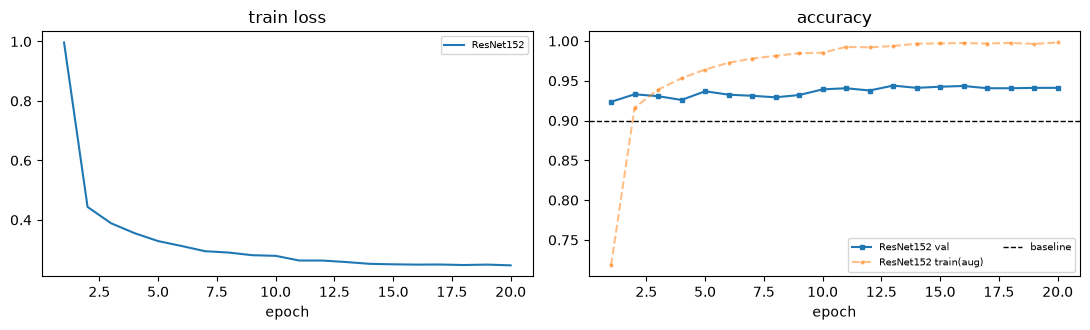

ResNet152        마지막 epoch  train 0.9982  vs  val 0.9411   차이 +0.0570

※ train 곡선은 '증강된' 이미지 기준이라 원본보다 낮게 나온다. 증강이 제대로 걸렸다면 train이 val보다 낮거나 비슷한 것이 정상이다.


In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
for mdl in MODELS:
    h = pd.DataFrame(final[mdl]["history"])
    ax[0].plot(h.epoch, h.loss, "-", label=mdl)
    ax[1].plot(h.epoch, h.val_acc, "s-", ms=3, label=f"{mdl} val")
    ax[1].plot(h.epoch, h.train_acc, "o--", ms=2, alpha=0.5, label=f"{mdl} train(aug)")
ax[0].set_title("train loss"); ax[0].set_xlabel("epoch"); ax[0].legend(fontsize=7)
ax[1].axhline(BASELINE_ACC, ls="--", c="k", lw=1, label="baseline")
ax[1].set_title("accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend(fontsize=7, ncol=2)
plt.tight_layout(); plt.show()

for mdl in MODELS:
    h = pd.DataFrame(final[mdl]["history"])
    print(f"{mdl:16s} 마지막 epoch  train {h.train_acc.iloc[-1]:.4f}  vs  val {h.val_acc.iloc[-1]:.4f}"
          f"   차이 {h.train_acc.iloc[-1]-h.val_acc.iloc[-1]:+.4f}")
print("\n※ train 곡선은 '증강된' 이미지 기준이라 원본보다 낮게 나온다. "
      "증강이 제대로 걸렸다면 train이 val보다 낮거나 비슷한 것이 정상이다.")

*(아래는 3-2의 증강을 적용하기 **전**, 원본 baseline 학습 곡선에 대한 설명입니다. 위 곡선과 비교해 보세요.)*

> ## 오른쪽 그래프의 두 선 사이 간격을 보세요
>
> 학습 정확도는 계속 올라가는데 검증 정확도는 어느 순간부터 안 올라갑니다.  
> **간격이 벌어지는 것 = 과적합**입니다. 모델이 문제를 푸는 게 아니라 **학습 이미지를 외우고** 있습니다.
>
> 지금 우리는 **정규화 말고는 아무 처리도 안 한 원본 이미지**를 매 epoch 똑같이 보여주고 있습니다.  
> 같은 사진 9천 장을 15번 반복해서 보면, 외우는 게 당연합니다.
>
> **데이터 증강**: 매번 **조금씩 다른 사진**을 보여주면 어떻게 될까요?  
> 좌우로 뒤집고, 살짝 잘라내고, 밝기를 바꾸면 — 사람 눈에는 여전히 같은 "숲"이지만  
> 모델에게는 새로운 이미지입니다.


ResNet152
              precision    recall  f1-score   support

   buildings     0.9451    0.9422    0.9437       329
      forest     0.9883    0.9912    0.9898       341
     glacier     0.9318    0.8698    0.8997       361
    mountain     0.8866    0.9337    0.9096       377
         sea     0.9736    0.9736    0.9736       341
      street     0.9474    0.9580    0.9526       357

    accuracy                         0.9440      2106
   macro avg     0.9455    0.9448    0.9448      2106
weighted avg     0.9443    0.9440    0.9439      2106

가장 흔한 혼동:  glacier -> mountain  (37건)


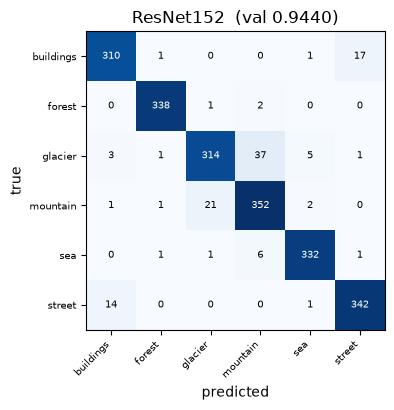

In [27]:
# 모델별 검증셋 오답 분석 : 어디서 틀리는지 봐야 다음 개선이 보인다
from sklearn.metrics import confusion_matrix, classification_report

_, val_eval = make_loaders(bs=128, strength="medium")      # 검증 로더는 증강이 없으므로 어떤 설정이든 동일

fig, ax = plt.subplots(1, len(MODELS), figsize=(4.6 * len(MODELS), 4.2), squeeze=False)
for k, mdl in enumerate(MODELS):
    m = final[mdl]["model"]
    m.load_state_dict(torch.load(f"best_{mdl}.pt"))        # 검증 최고 시점으로 되돌린다
    m.eval()
    yp, yt = [], []
    with torch.no_grad():
        for xb, yb in val_eval:
            with torch.amp.autocast(DEVICE, enabled=USE_AMP):
                yp.append(m(xb.to(DEVICE)).argmax(1).cpu())
            yt.append(yb)
    yp, yt = torch.cat(yp).numpy(), torch.cat(yt).numpy()

    cm = confusion_matrix(yt, yp)
    a  = ax[0, k]
    a.imshow(cm, cmap="Blues")
    a.set_xticks(range(len(CLASSES))); a.set_xticklabels(CLASSES, rotation=45, ha="right", fontsize=7)
    a.set_yticks(range(len(CLASSES))); a.set_yticklabels(CLASSES, fontsize=7)
    a.set_xlabel("predicted"); a.set_ylabel("true"); a.set_title(f"{mdl}  (val {final[mdl]['best_acc']:.4f})")
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            a.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                   color="white" if cm[i, j] > cm.max() * 0.5 else "black")

    print(f"\n{'='*60}\n{mdl}\n{'='*60}")
    print(classification_report(yt, yp, target_names=CLASSES, digits=4))
    off = cm - np.diag(np.diag(cm))
    i, j = np.unravel_index(off.argmax(), off.shape)
    print(f"가장 흔한 혼동:  {CLASSES[i]} -> {CLASSES[j]}  ({off[i,j]}건)")

plt.tight_layout(); plt.show()

## 6. 제출 파일 만들기

모델마다 **`submission_<모델>.csv`** 를 따로 만듭니다. 어느 파일을 캐글에 낼지는 직접 고르면 됩니다.

테스트셋에는 증강을 적용하지 않고, 3-1의 `batches()`(정규화만)를 그대로 씁니다 —
학습에 쓴 albumentations의 `Normalize`와 같은 ImageNet 상수라 결과가 일치합니다.

In [28]:
rows = []
for mdl in MODELS:
    m = final[mdl]["model"]
    m.load_state_dict(torch.load(f"best_{mdl}.pt"))       # 검증 최고 시점으로 되돌린다
    m.eval()
    preds = []
    with torch.no_grad():
        for xb, _ in batches(Xte, None, np.arange(len(Xte)), 256, False):
            with torch.amp.autocast(DEVICE, enabled=USE_AMP):
                preds.append(m(xb).argmax(1).cpu())
    pred = torch.cat(preds).numpy()

    submission = pd.DataFrame({"id": sub["id"], "label": [CLASSES[i] for i in pred]})
    assert len(submission) == len(sub),             f"행 수 불일치 {len(submission)} vs {len(sub)}"
    assert set(submission["id"]) == set(sub["id"]), "id 집합 불일치"
    assert set(submission["label"]) <= set(CLASSES), "허용되지 않는 클래스 값"

    path = f"submission_{mdl}.csv"
    submission.to_csv(path, index=False)
    rows.append({"model": mdl, "val_acc": final[mdl]["best_acc"], "file": path})

    print(f"\n{path} 생성 완료  (val {final[mdl]['best_acc']:.4f})")
    print("예측 분포(%) " + (submission["label"].value_counts(normalize=True) * 100)
          .round(2).to_dict().__str__())

print("\n학습 분포(%) " + (train_df["label"].value_counts(normalize=True) * 100).round(2).to_dict().__str__())
print(f"\n{'='*60}")
print(pd.DataFrame(rows).sort_values("val_acc", ascending=False).round(4).to_string(index=False))


submission_ResNet152.csv 생성 완료  (val 0.9440)
예측 분포(%) {'mountain': 17.87, 'sea': 17.57, 'glacier': 17.4, 'street': 16.47, 'forest': 15.87, 'buildings': 14.83}

학습 분포(%) {'mountain': 17.9, 'glacier': 17.13, 'street': 16.97, 'sea': 16.2, 'forest': 16.18, 'buildings': 15.61}

    model  val_acc                     file
ResNet152    0.944 submission_ResNet152.csv
